# 01 — Basic entropy trajectory

`entropy-lens` turns the `logprobs` field of an OpenAI-compatible response
(OpenAI, vLLM, SGLang) into a per-token **entropy trajectory** — no extra
sampling, no second model, just the logprobs you already got from a single
forward pass.

```bash
pip install "entropy-lens[viz]"
```

This notebook uses a saved vLLM response so it runs without any server.

In [1]:
import json
from pathlib import Path

from entropy_lens.adapters import from_openai_response

response = json.loads(Path("../tests/fixtures/vllm_response.json").read_text())
traj = from_openai_response(response)
traj.text

'The capital of France is Paris.'

## Per-token entropy

Each position's Shannon entropy $H = -\sum_i p_i \log_2 p_i$ is computed
from the top-k logprobs (in **bits** by default, so perplexity is $2^H$ —
the *effective number of plausible next tokens*).

In [2]:
from entropy_lens import perplexity_from_entropy

print(f"{'token':<12} | {'H (bits)':>8} | {'perplexity':>10}")
print("-" * 38)
for tok, h in zip(traj.tokens, traj.entropies, strict=True):
    print(f"{tok!r:<12} | {h:8.4f} | {float(perplexity_from_entropy(h)):10.3f}")

token        | H (bits) | perplexity
--------------------------------------
'The'        |   1.7961 |      3.473
' capital'   |   0.3849 |      1.306
' of'        |   0.0895 |      1.064
' France'    |   0.2252 |      1.169
' is'        |   0.1375 |      1.100
' Paris'     |   0.0566 |      1.040
'.'          |   1.0766 |      2.109


Obvious continuations (` of`, ` Paris`) are near 0 bits, while the opener
`The` and the final punctuation are genuinely uncertain — several
continuations were plausible there.

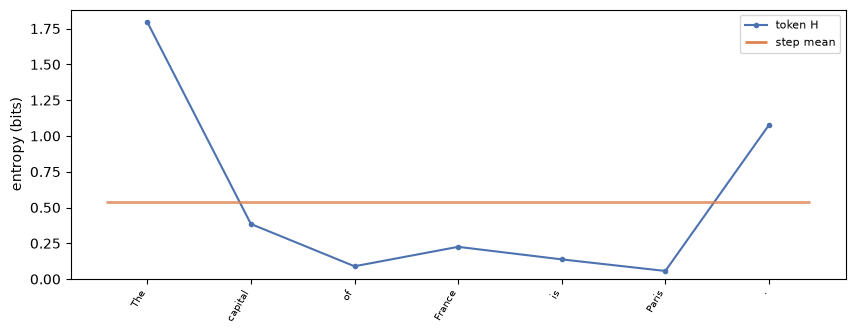

In [3]:
from entropy_lens.viz import plot_token_entropies

plot_token_entropies(traj, show_tokens=True);

## Getting a response like this yourself

Any OpenAI-compatible endpoint works — just ask for logprobs:

```python
from openai import OpenAI

client = OpenAI(base_url="http://localhost:8000/v1", api_key="EMPTY")
response = client.chat.completions.create(
    model="Qwen/Qwen2.5-0.5B-Instruct",
    messages=[{"role": "user", "content": "What is the capital of France?"}],
    logprobs=True,
    top_logprobs=20,
)
traj = from_openai_response(response)  # SDK objects work directly
```

**Caveat**: with only top-k logprobs the entropy is an *estimate*
(`tail="ignore"` renormalizes and tends to underestimate; `tail="uniform"`
gives an upper-bound-style estimate). And low entropy means *confidence*,
not *correctness* — a model can be confidently wrong.